In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Projekt Zespołowy/Dane/dane/calendar.csv", parse_dates=["date"])
df = df.sort_values(["listing_id", "date"])

In [ ]:
df

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,70820,2025-09-26,f,NaN,NaN,4,30
1,70820,2025-09-27,f,NaN,NaN,4,30
2,70820,2025-09-28,f,NaN,NaN,4,30
3,70820,2025-09-29,f,NaN,NaN,4,30
4,70820,2025-09-30,t,NaN,NaN,4,30
...,...,...,...,...,...,...,...
494570,1518113294243873256,2026-09-21,t,NaN,NaN,2,365
494571,1518113294243873256,2026-09-22,t,NaN,NaN,2,365
494572,1518113294243873256,2026-09-23,t,NaN,NaN,2,365
494573,1518113294243873256,2026-09-24,t,NaN,NaN,2,365


In [ ]:
df['price'].value_counts()

,count
price,


In [ ]:
df= df.drop(columns=["price","adjusted_price"])

In [ ]:
le = LabelEncoder()
df['available'] = le.fit_transform(df['available'])
df

,listing_id,date,available,minimum_nights,maximum_nights
0,70820,2025-09-26,0,4,30
1,70820,2025-09-27,0,4,30
2,70820,2025-09-28,0,4,30
3,70820,2025-09-29,0,4,30
4,70820,2025-09-30,1,4,30
...,...,...,...,...,...
494570,1518113294243873256,2026-09-21,1,2,365
494571,1518113294243873256,2026-09-22,1,2,365
494572,1518113294243873256,2026-09-23,1,2,365
494573,1518113294243873256,2026-09-24,1,2,365


In [ ]:
df["available_num"] = df["available"].astype(int)
df["change"] = df.groupby("listing_id")["available_num"].diff().ne(0).cumsum()

In [ ]:
summary = df.groupby("listing_id").agg(
    availability_rate=("available_num", "mean"),
    available_days=("available_num", "sum"),
    unavailable_days=("available", lambda x: (x == False).sum()),
    total_days=("available_num", "count"),
    min_nights=("minimum_nights", "mean"),
    max_nights=("maximum_nights", "mean"),
    changes=("change", "nunique")).reset_index()
summary

,listing_id,availability_rate,available_days,unavailable_days,total_days,min_nights,max_nights,changes
0,70820,0.060274,22,343,365,4.0,30.0,5
1,117122,0.958904,350,15,365,1.0,28.0,8
2,176306,0.361644,132,233,365,5.0,32.0,3
3,307634,0.657534,240,125,365,4.0,1125.0,3
4,390781,0.000000,0,365,365,2.0,100.0,1
...,...,...,...,...,...,...,...,...
2840,1516614129503593390,0.991781,362,3,365,3.0,365.0,2
2841,1517270444075292362,1.000000,365,0,365,3.0,365.0,1
2842,1517370864228833233,0.243836,89,276,365,2.0,365.0,3
2843,1517941386150332084,0.997260,364,1,365,2.0,365.0,2


In [ ]:
summary.to_csv('/content/drive/MyDrive/Projekt Zespołowy/Dane/dane/calendar_summary.csv', index=False)

In [ ]:
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday

In [ ]:
df

,listing_id,date,available,minimum_nights,maximum_nights,available_num,change,month,weekday
0,70820,2025-09-26,0,4,30,0,1,9,4
1,70820,2025-09-27,0,4,30,0,1,9,5
2,70820,2025-09-28,0,4,30,0,1,9,6
3,70820,2025-09-29,0,4,30,0,1,9,0
4,70820,2025-09-30,1,4,30,1,2,9,1
...,...,...,...,...,...,...,...,...,...
494570,1518113294243873256,2026-09-21,1,2,365,1,24567,9,0
494571,1518113294243873256,2026-09-22,1,2,365,1,24567,9,1
494572,1518113294243873256,2026-09-23,1,2,365,1,24567,9,2
494573,1518113294243873256,2026-09-24,1,2,365,1,24567,9,3


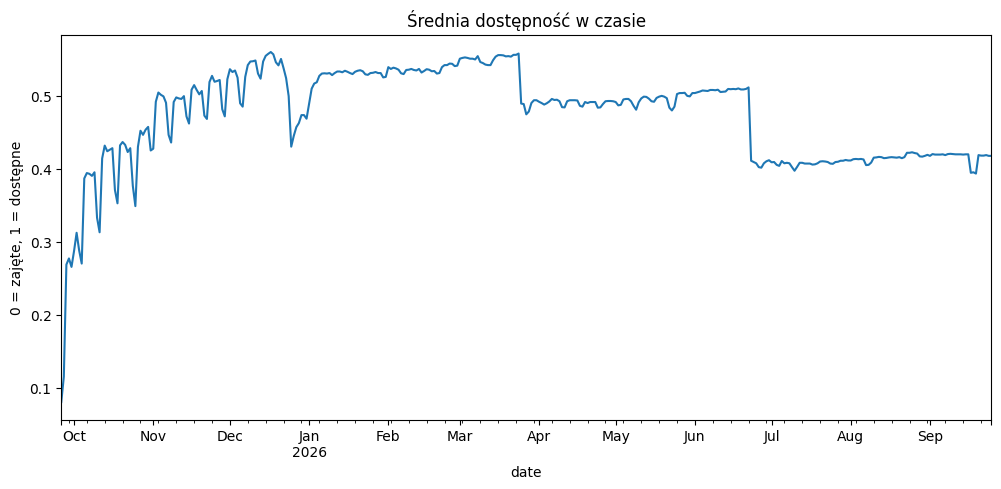

In [ ]:
daily = df.groupby("date")["available_num"].mean()

daily.plot(figsize=(12,5))
plt.title("Średnia dostępność w czasie")
plt.ylabel("0 = zajęte, 1 = dostępne")
plt.show()

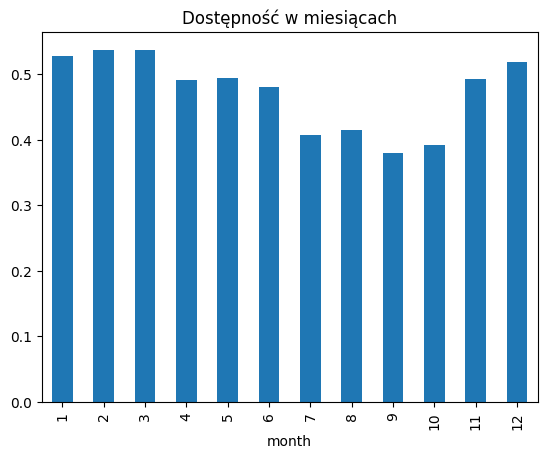

In [ ]:
monthly = df.groupby("month")["available_num"].mean()

monthly.plot(kind="bar")
plt.title("Dostępność w miesiącach")
plt.show()

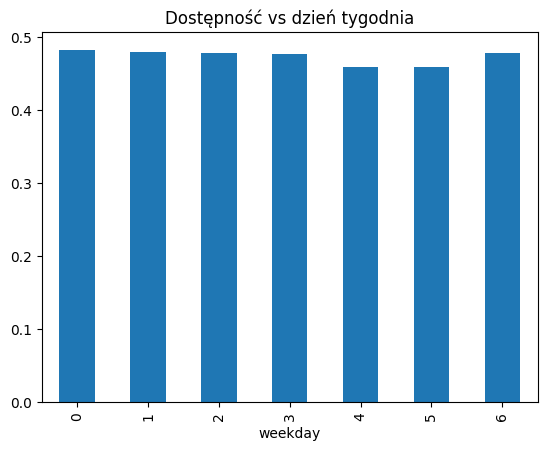

In [ ]:
weekday = df.groupby("weekday")["available_num"].mean()

weekday.plot(kind="bar")
plt.title("Dostępność vs dzień tygodnia")
plt.show()

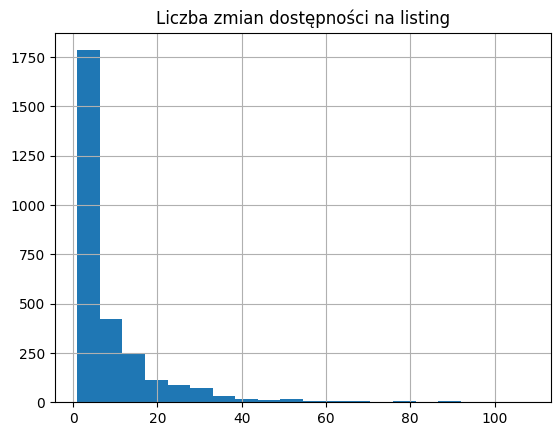

In [ ]:
changes = df.groupby("listing_id")["change"].nunique()

changes.hist(bins=20)
plt.title("Liczba zmian dostępności na listing")
plt.show()

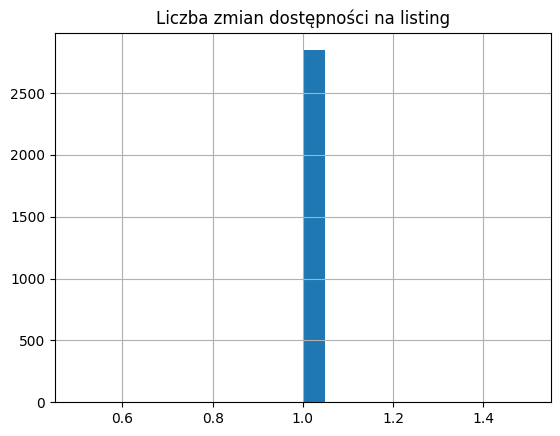

In [ ]:
changes2 = summary.groupby("listing_id")["availability_rate"].nunique()

changes2.hist(bins=20)
plt.title("Liczba zmian dostępności na listing")
plt.show()

In [ ]:
df.to_csv('/content/drive/MyDrive/Projekt Zespołowy/Dane/dane/calendar_v2.csv', index=False)